# **Actividad - Clasificación**
Caso 5 - Laura Chavarriaga, Natalia Mejía y Juan Pablo Monsalve

## **1. Entendimiento del negocio**
Una organización financiera requiere estimar el rango de ingresos de clientes potenciales cuando esta información no está disponible, es incompleta o puede no ser totalmente confiable. Contar con esta estimación permite mejorar la segmentación comercial, priorizar prospectos con mayor probabilidad de adquirir productos y diseñar campañas más efectivas para ofertas. 

## **2. Enfoque analítico**
Desarrollar un experimento de clasificación para determinar rangos de ingresos en una población de diferentes edades con un desempeño esperado mayor al 85%.

## **3. Requerimiento de datos**
- Datos demográficos de la muestra poblacional
- Datos de comportamiento de la muestra poblacional
- Datos financieros de la muestra poblacional
- Rango de ingresos

## **4. Recolección de datos**
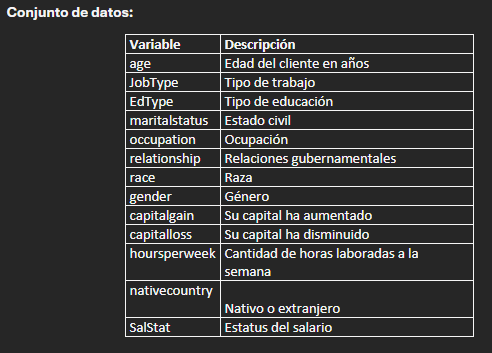

In [1]:
import pandas as pd
import numpy as np
data = pd.read_csv('datos_caso_5.csv')
data.head()

,age,JobType,EdType,maritalstatus,occupation,relationship,race,gender,capitalgain,capitalloss,hoursperweek,nativecountry,SalStat
0,45,Private,HS-grad,Divorced,Adm-clerical,Not-in-family,White,Female,0,0,28,United-States,"less than or equal to 50,000"
1,24,Federal-gov,HS-grad,Never-married,Armed-Forces,Own-child,White,Male,0,0,40,United-States,"less than or equal to 50,000"
2,44,Private,Some-college,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,40,United-States,"greater than 50,000"
3,27,Private,9th,Never-married,Craft-repair,Other-relative,White,Male,0,0,40,Mexico,"less than or equal to 50,000"
4,20,Private,Some-college,Never-married,Sales,Not-in-family,White,Male,0,0,35,United-States,"less than or equal to 50,000"


## **5. Entendimiento de los Datos**

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 31978 entries, 0 to 31977
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   age            31978 non-null  int64
 1   JobType        31978 non-null  str  
 2   EdType         31978 non-null  str  
 3   maritalstatus  31978 non-null  str  
 4   occupation     31978 non-null  str  
 5   relationship   31978 non-null  str  
 6   race           31978 non-null  str  
 7   gender         31978 non-null  str  
 8   capitalgain    31978 non-null  int64
 9   capitalloss    31978 non-null  int64
 10  hoursperweek   31978 non-null  int64
 11  nativecountry  31978 non-null  str  
 12  SalStat        31978 non-null  str  
dtypes: int64(4), str(9)
memory usage: 3.2 MB


Vemos del .info() que los datos parecen estar completos y por tanto no hay nulos explicitos.

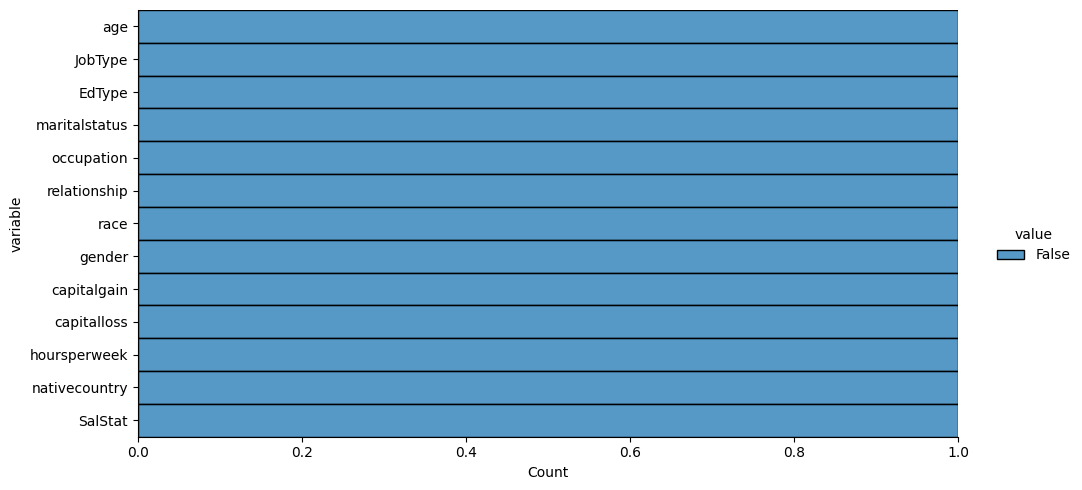

In [4]:
data.isnull().melt().pipe(lambda df: sns.displot(data=df, y='variable',hue='value',multiple='fill',aspect=2))

<function matplotlib.pyplot.show(close=None, block=None)>

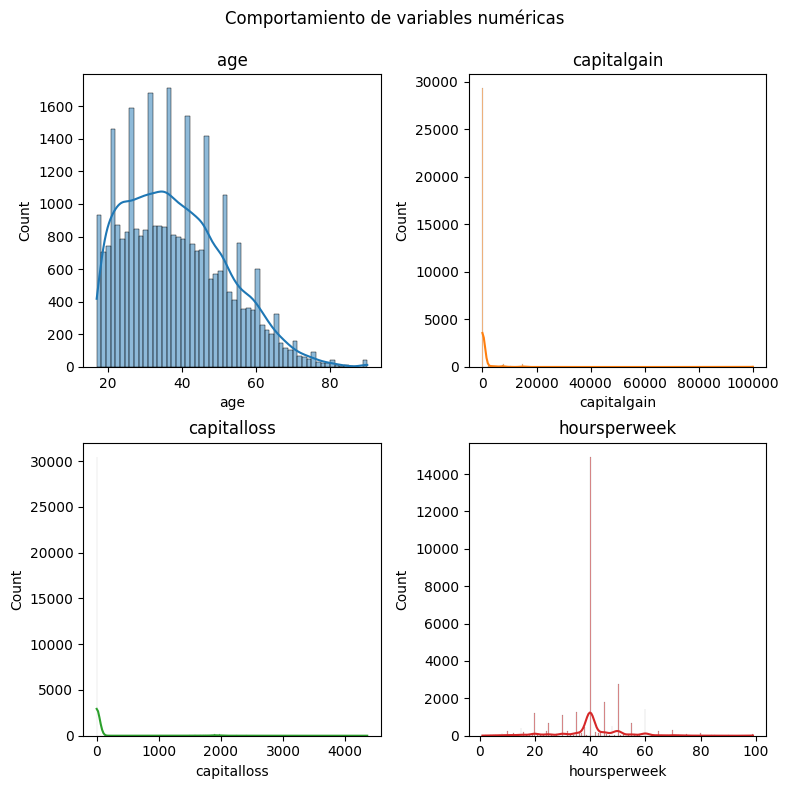

In [5]:
#Gráficos de Histogramas de Frecuencias
fig, ax = plt.subplots(2,2,figsize=(8,8))
ax = ax.flat
num_col = data.select_dtypes(include={'int64','float64'}).columns
for i, col in enumerate(num_col):
    sns.histplot(data=data, x=col, kde=True,
                 color = (list(plt.rcParams['axes.prop_cycle'])*7)[i]['color'],
                 ax = ax[i])
    ax[i].set_title(col)
fig.tight_layout()
fig.subplots_adjust(top=0.9)
fig.suptitle('Comportamiento de variables numéricas')
plt.show



In [6]:
data.describe()

,age,capitalgain,capitalloss,hoursperweek
count,31978.000000,31978.000000,31978.000000,31978.000000
mean,38.579023,1064.360623,86.739352,40.417850
std,13.662085,7298.596271,401.594301,12.345285
min,17.000000,0.000000,0.000000,1.000000
25%,28.000000,0.000000,0.000000,40.000000
50%,37.000000,0.000000,0.000000,40.000000
75%,48.000000,0.000000,0.000000,45.000000
max,90.000000,99999.000000,4356.000000,99.000000


No hay que hacer ninguna conversion a string

<function matplotlib.pyplot.show(close=None, block=None)>

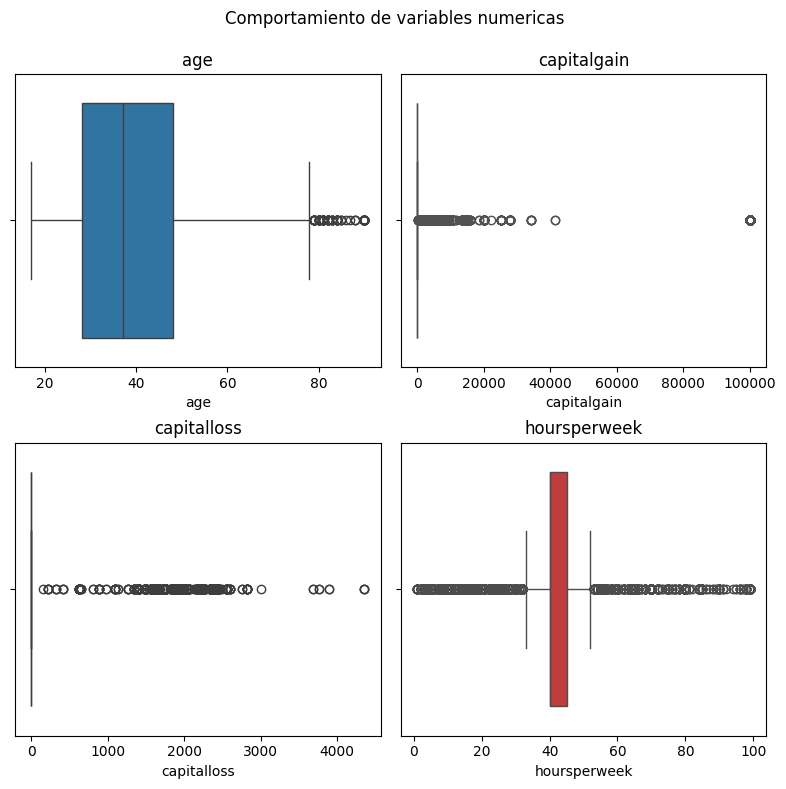

In [7]:
fig, ax = plt.subplots(2,2,figsize = (8,8))
ax = ax.flat
num_col = data.select_dtypes(include={'int64','float64'}).columns
for i, col in enumerate(num_col):
    sns.boxplot(data = data, x = col,
    color = (list(plt.rcParams['axes.prop_cycle'])*7)[i]['color'], 
    ax = ax[i])
    ax[i].set_title(col)
fig.tight_layout()
fig.subplots_adjust(top=0.9)
fig.suptitle('Comportamiento de variables numericas')
plt.show

Todos los valores atípicos son naturales, entonces ni hacemos ventaneo ni transformamos a nulos.

In [8]:
data.describe(include=['object'])

C:\Users\juanp\AppData\Local\Temp\ipykernel_26064\1736911641.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.describe(include=['object'])


,JobType,EdType,maritalstatus,occupation,relationship,race,gender,nativecountry,SalStat
count,31978,31978,31978,31978,31978,31978,31978,31978,31978
unique,9,16,7,15,6,5,2,41,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,"less than or equal to 50,000"
freq,22286,10368,14692,4038,12947,27430,21370,29170,24283


In [9]:
data.JobType.value_counts()

JobType
Private             22286
Self-emp-not-inc     2499
Local-gov            2067
?                    1809
State-gov            1279
Self-emp-inc         1074
Federal-gov           943
Without-pay            14
Never-worked            7
Name: count, dtype: int64

In [10]:
data.occupation.value_counts()

occupation
Prof-specialty       4038
Craft-repair         4030
Exec-managerial      3992
Adm-clerical         3721
Sales                3584
Other-service        3212
Machine-op-inspct    1966
?                    1816
Transport-moving     1572
Handlers-cleaners    1350
Farming-fishing       989
Tech-support          912
Protective-serv       644
Priv-house-serv       143
Armed-Forces            9
Name: count, dtype: int64

C:\Users\juanp\AppData\Local\Temp\ipykernel_26064\545029320.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_col = data.select_dtypes(include={'object'}).columns


<function matplotlib.pyplot.show(close=None, block=None)>

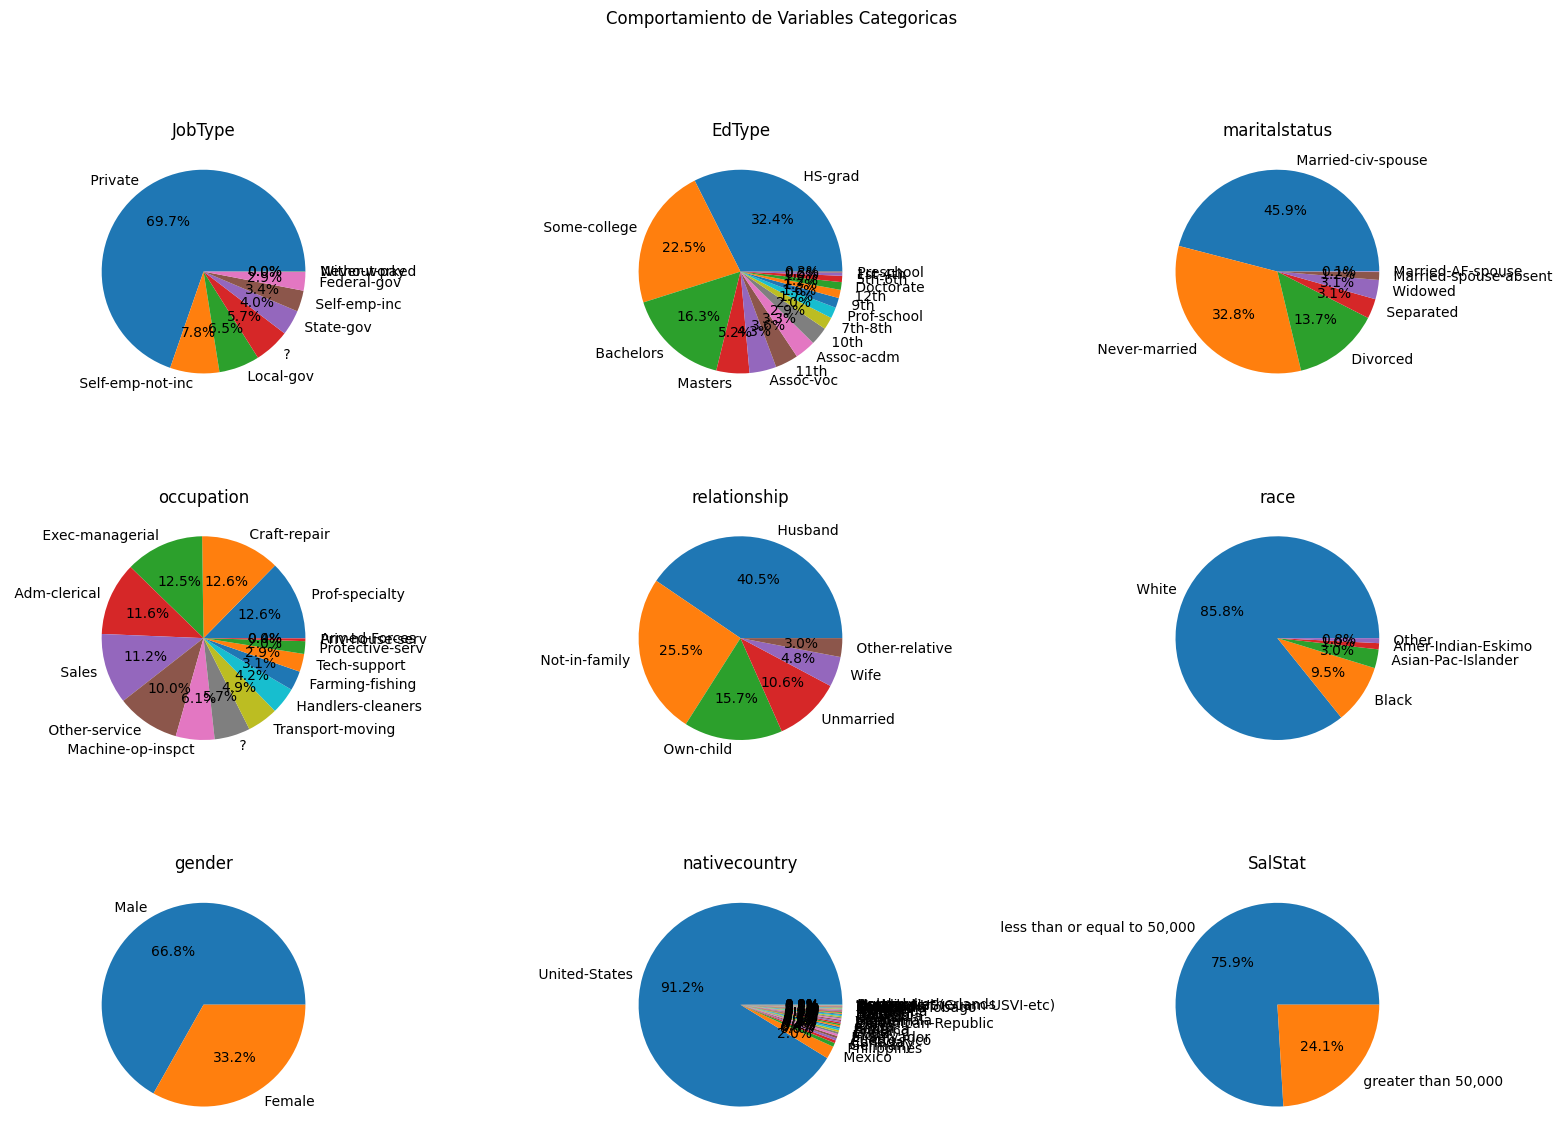

In [11]:
# Gráficos de Torta para variables categoricas
fig, ax = plt.subplots(3,3,figsize = (15,12))
ax = ax.flat
cat_col = data.select_dtypes(include={'object'}).columns
for i, col in enumerate(cat_col):
    ax[i].pie(x = data[col].value_counts(), labels = data[col].value_counts().index, autopct = "%0.1f%%")
    ax[i].set_title(col)
fig.tight_layout()
fig.subplots_adjust(top=0.9)
fig.suptitle('Comportamiento de Variables Categoricas')
plt.show


-  Ignoramos las variables con desbalance mayor a 80% (`nativecountry` y `race`).
- Y balanceamos la y (`SalStat`)
- Tenemos que tener en cuenta otra cosa importante, y es que tanto `JobType` como `occupation` tienen una categoría "?" que es un nulo implicito, entonces hay que transformarlo en explicito.

In [12]:
data.JobType = data.JobType.replace({' ?': np.nan})
data.occupation = data.occupation.replace({' ?': np.nan})
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 31978 entries, 0 to 31977
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   age            31978 non-null  int64
 1   JobType        30169 non-null  str  
 2   EdType         31978 non-null  str  
 3   maritalstatus  31978 non-null  str  
 4   occupation     30162 non-null  str  
 5   relationship   31978 non-null  str  
 6   race           31978 non-null  str  
 7   gender         31978 non-null  str  
 8   capitalgain    31978 non-null  int64
 9   capitalloss    31978 non-null  int64
 10  hoursperweek   31978 non-null  int64
 11  nativecountry  31978 non-null  str  
 12  SalStat        31978 non-null  str  
dtypes: int64(4), str(9)
memory usage: 3.2 MB


In [13]:
data_clean = data.copy()
data_clean.dropna(inplace=True)
data_clean.info()

<class 'pandas.DataFrame'>
Index: 30162 entries, 0 to 31977
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   age            30162 non-null  int64
 1   JobType        30162 non-null  str  
 2   EdType         30162 non-null  str  
 3   maritalstatus  30162 non-null  str  
 4   occupation     30162 non-null  str  
 5   relationship   30162 non-null  str  
 6   race           30162 non-null  str  
 7   gender         30162 non-null  str  
 8   capitalgain    30162 non-null  int64
 9   capitalloss    30162 non-null  int64
 10  hoursperweek   30162 non-null  int64
 11  nativecountry  30162 non-null  str  
 12  SalStat        30162 non-null  str  
dtypes: int64(4), str(9)
memory usage: 3.2 MB


In [14]:
(31978-30162)/31978 *100

5.678904246669585

Sin embargo, vemos que no hay que hacer imputación de datos nulos porque si eliminamos esos datos, perdemos solo aproximadamente 5.6789% de los datos, que es menor al 10% permitido para eliminar registros.

In [15]:
data.dropna(inplace=True)
data.info()

<class 'pandas.DataFrame'>
Index: 30162 entries, 0 to 31977
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   age            30162 non-null  int64
 1   JobType        30162 non-null  str  
 2   EdType         30162 non-null  str  
 3   maritalstatus  30162 non-null  str  
 4   occupation     30162 non-null  str  
 5   relationship   30162 non-null  str  
 6   race           30162 non-null  str  
 7   gender         30162 non-null  str  
 8   capitalgain    30162 non-null  int64
 9   capitalloss    30162 non-null  int64
 10  hoursperweek   30162 non-null  int64
 11  nativecountry  30162 non-null  str  
 12  SalStat        30162 non-null  str  
dtypes: int64(4), str(9)
memory usage: 3.2 MB


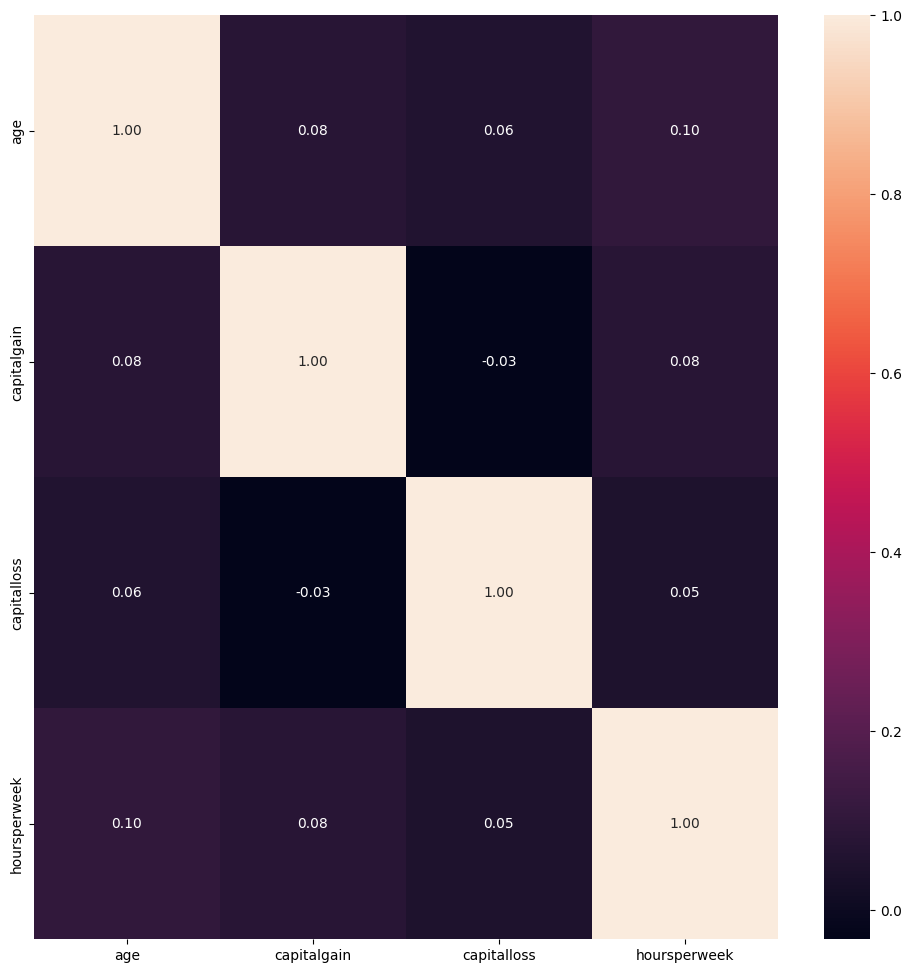

In [16]:
plt.figure(figsize = (12,12))
sns.heatmap(data = data.corr(numeric_only=True),annot=True, fmt='0.2f')
plt.show()

Todas las variables presentan relación nula.
No hay riesgo de multicolinealidad.

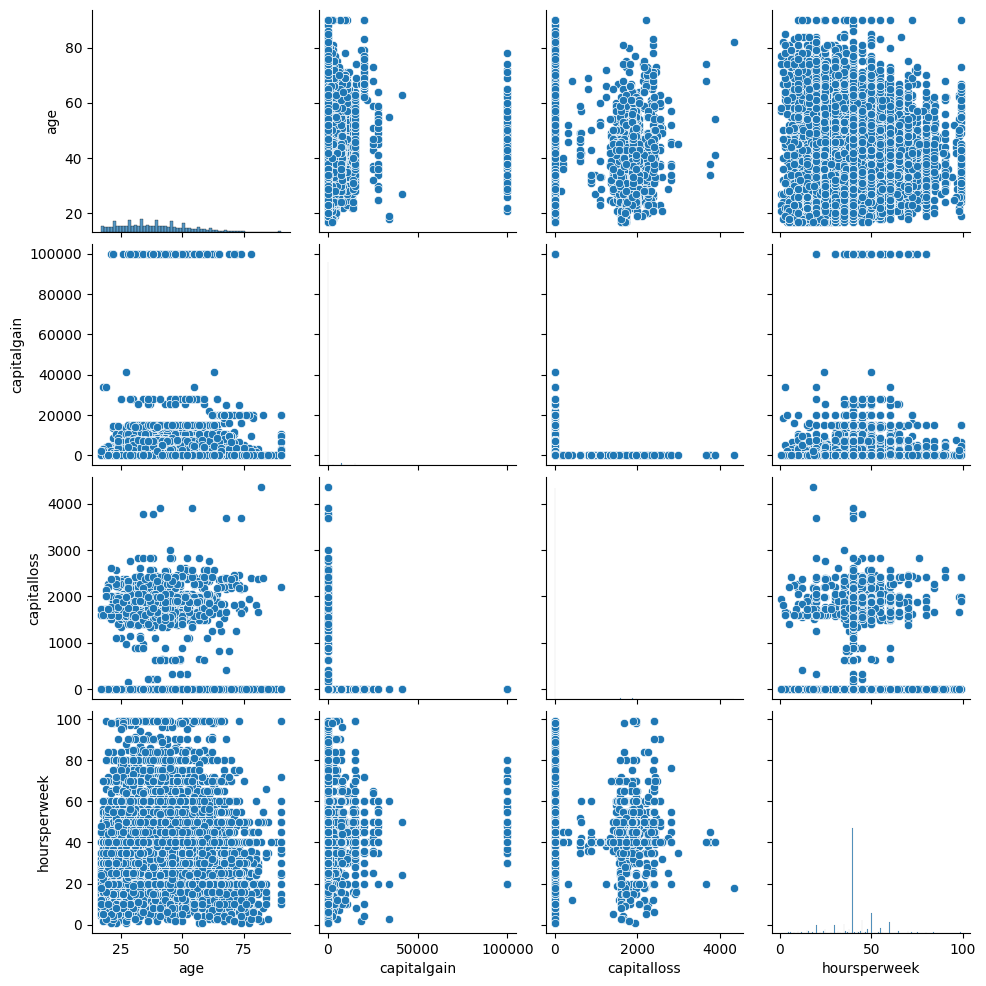

In [17]:
sns.pairplot(data=data)

## **6. Preparación de los Datos**
- Ignorar las variables poco representativas 
- Balancear la variable y
- Transformar las variables numéricas y categóricas
- Separar en conjuntos de entrenamiento y validación

In [18]:
data_mod = data.drop(columns=['nativecountry','race'])

In [19]:
data_mod.SalStat.unique()

<StringArray>
[' less than or equal to 50,000', ' greater than 50,000']
Length: 2, dtype: str

In [20]:
data_greater = data_mod[data_mod['SalStat']==' greater than 50,000']
data_lower = data_mod[data_mod['SalStat']==' less than or equal to 50,000']

print(f'El tamaño de la clase greater than 50000 es: {data_greater.shape}\nEl tamaño de la clase less than or equal to 50000 es {data_lower.shape}')

El tamaño de la clase greater than 50000 es: (7508, 11)
El tamaño de la clase less than or equal to 50000 es (22654, 11)


In [21]:
data_greater_re = data_greater.sample(data_lower.shape[0], replace=True)
data_balanced = pd.concat([data_lower,data_greater_re])
data_balanced.reset_index(drop=True, inplace=True)
data_balanced.info()

<class 'pandas.DataFrame'>
RangeIndex: 45308 entries, 0 to 45307
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   age            45308 non-null  int64
 1   JobType        45308 non-null  str  
 2   EdType         45308 non-null  str  
 3   maritalstatus  45308 non-null  str  
 4   occupation     45308 non-null  str  
 5   relationship   45308 non-null  str  
 6   gender         45308 non-null  str  
 7   capitalgain    45308 non-null  int64
 8   capitalloss    45308 non-null  int64
 9   hoursperweek   45308 non-null  int64
 10  SalStat        45308 non-null  str  
dtypes: int64(4), str(7)
memory usage: 3.8 MB


<function matplotlib.pyplot.show(close=None, block=None)>

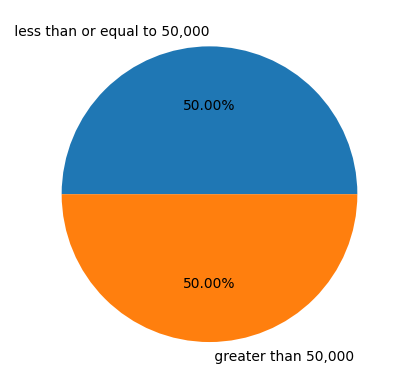

In [22]:
plt.pie(x=data_balanced.SalStat.value_counts(), labels=data.SalStat.value_counts().index, autopct = '%0.2f%%')
plt.show

Ya la variable objetivo y está balanceada.

In [23]:
data_x = data_balanced.copy()
data_x.drop(columns='SalStat', inplace=True)
data_y = data_balanced[['SalStat']]

In [24]:
data_x.info()

<class 'pandas.DataFrame'>
RangeIndex: 45308 entries, 0 to 45307
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   age            45308 non-null  int64
 1   JobType        45308 non-null  str  
 2   EdType         45308 non-null  str  
 3   maritalstatus  45308 non-null  str  
 4   occupation     45308 non-null  str  
 5   relationship   45308 non-null  str  
 6   gender         45308 non-null  str  
 7   capitalgain    45308 non-null  int64
 8   capitalloss    45308 non-null  int64
 9   hoursperweek   45308 non-null  int64
dtypes: int64(4), str(6)
memory usage: 3.5 MB


In [25]:
data_y.info()

<class 'pandas.DataFrame'>
RangeIndex: 45308 entries, 0 to 45307
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   SalStat  45308 non-null  str  
dtypes: str(1)
memory usage: 354.1 KB


In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

In [27]:
num_cols = data_x.select_dtypes(include={'int64','float64'}).columns.to_list()
cat_cols = data_x.select_dtypes(include={'object'}).columns.to_list()
num_transformer = Pipeline(steps = [('scaler', MinMaxScaler())])
cat_transformer = Pipeline(steps = [('encoder', OneHotEncoder(sparse_output=False))])
preprocessor = ColumnTransformer(transformers=[('num',num_transformer,num_cols),('cat',cat_transformer,cat_cols)], remainder='passthrough')
preprocessor

C:\Users\juanp\AppData\Local\Temp\ipykernel_26064\437652202.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = data_x.select_dtypes(include={'object'}).columns.to_list()


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``.

In [28]:
data_pre = preprocessor.fit_transform(data_x)
cod_cat = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(cat_cols)
labels = np.concatenate([num_cols, cod_cat])
data_pro = pd.DataFrame(data_pre, columns=labels)
data_pro.head()

,age,capitalgain,capitalloss,hoursperweek,JobType_ Federal-gov,JobType_ Local-gov,JobType_ Private,JobType_ Self-emp-inc,JobType_ Self-emp-not-inc,JobType_ State-gov,...,occupation_ Tech-support,occupation_ Transport-moving,relationship_ Husband,relationship_ Not-in-family,relationship_ Other-relative,relationship_ Own-child,relationship_ Unmarried,relationship_ Wife,gender_ Female,gender_ Male
0,0.383562,0.0,0.0,0.275510,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.095890,0.0,0.0,0.397959,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,0.136986,0.0,0.0,0.397959,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,0.041096,0.0,0.0,0.346939,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.369863,0.0,0.0,0.397959,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


Usamos OneHotEncoder para codificar las variables categoricas porque ninguna pasa del limite establecido.

In [29]:
data_y

,SalStat
0,"less than or equal to 50,000"
1,"less than or equal to 50,000"
2,"less than or equal to 50,000"
3,"less than or equal to 50,000"
4,"less than or equal to 50,000"
...,...
45303,"greater than 50,000"
45304,"greater than 50,000"
45305,"greater than 50,000"
45306,"greater than 50,000"


In [30]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(data_pro,data_y,train_size=0.7, random_state=123)
print(f'El tamaño del conjunto de entrenamiento es: {X_train.shape}{y_train.shape}\nEl tamaño del conjunto de validación es: {X_test.shape}{y_test.shape}')

El tamaño del conjunto de entrenamiento es: (31715, 56)(31715, 1)
El tamaño del conjunto de validación es: (13593, 56)(13593, 1)


<function matplotlib.pyplot.show(close=None, block=None)>

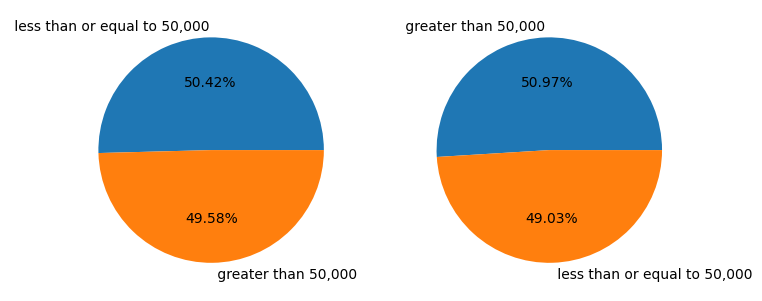

In [31]:
fig, ax = plt.subplots(1,2,figsize=(8,8))
ax[0].pie(x=y_train.SalStat.value_counts(), labels= y_train.SalStat.value_counts().index, autopct = '%0.2f%%')
ax[1].pie(x=y_test.SalStat.value_counts(), labels=y_test.SalStat.value_counts().index, autopct = '%0.2f%%')
plt.show

## **7. Modelado de Datos**
- Regresión Lógistica
- K Vecinos Más Cercanos
- Máquina de Soporte Vectorial
- Árbol de Decisión
- Extra Tree Classifier
- Random Forest
- Adaptative Boosting
- Gradient Boosting
- Red Neuronal Artificial

In [32]:
import warnings
warnings.filterwarnings('ignore')

### Regresión Logistica

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
model_1 = LogisticRegression(solver='saga', random_state=123)
param_grid = {'penalty':['l1','l2','elasticnet'], 'C':[0.001,0.01,0.1,1,10,100,1000]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
clf_1 = GridSearchCV(estimator=model_1, param_grid=param_grid, cv=cv, scoring='f1_weighted', n_jobs=-1)
clf_1.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...solver='saga')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'penalty': ['l1', 'l2', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 :

In [34]:
validation = pd.concat([pd.DataFrame(clf_1.cv_results_['params']),
                        pd.DataFrame(clf_1.cv_results_['mean_test_score'],columns = ['F1_score'])], axis = 1)
validation.sort_values('F1_score', ascending=False)

,C,penalty,F1_score
20,1000.000,elasticnet,0.818916
19,1000.000,l2,0.818916
18,1000.000,l1,0.818884
15,100.000,l1,0.818884
12,10.000,l1,0.818852
17,100.000,elasticnet,0.818851
16,100.000,l2,0.818851
14,10.000,elasticnet,0.818848
13,10.000,l2,0.818848
9,1.000,l1,0.818787


### K Vecinos Más Cercanos

In [35]:
from sklearn.neighbors import KNeighborsClassifier
model_2 = KNeighborsClassifier()
param_grid = {'n_neighbors':[3,5,9,7,11,15,101],'p':[1,2]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
clf_2 = GridSearchCV(estimator=model_2, param_grid = param_grid, cv=cv, scoring='f1_weighted', n_jobs=-1)
clf_2.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': [3, 5, ...], 'p': [1, 2]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also dis

In [36]:
validation = pd.concat([pd.DataFrame(clf_2.cv_results_['params']),
                        pd.DataFrame(clf_2.cv_results_['mean_test_score'],columns = ['F1_score'])], axis = 1)
validation.sort_values('F1_score', ascending=False)

,n_neighbors,p,F1_score
0,3,1,0.833897
1,3,2,0.832944
2,5,1,0.819688
3,5,2,0.819494
6,7,1,0.814770
7,7,2,0.814406
8,11,1,0.813938
5,9,2,0.813841
9,11,2,0.813654
4,9,1,0.813177


### Máquina de Soporte Vectorial

In [37]:
from sklearn.svm import SVC
model_3 = SVC(random_state = 123)
param_grid = {'C':[0.001,0.01,0.1,10,100], "kernel":['poly','linear','rbf','sigmoid'],'degree':[2,3]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state = 123)
clf_3 = GridSearchCV(estimator=model_3, param_grid=param_grid, cv=cv, scoring='f1_weighted', n_jobs=-1)
clf_3.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(random_state=123)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'degree': [2, 3], 'kernel': ['poly', 'linear', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is di

In [38]:
validation = pd.concat([pd.DataFrame(clf_3.cv_results_['params']),
                        pd.DataFrame(clf_3.cv_results_['mean_test_score'],columns = ['F1_score'])], axis = 1)
validation.sort_values('F1_score', ascending=False)

,C,degree,kernel,F1_score
38,100.000,3,rbf,0.839323
34,100.000,2,rbf,0.839323
36,100.000,3,poly,0.834919
26,10.000,2,rbf,0.832553
30,10.000,3,rbf,0.832553
28,10.000,3,poly,0.830818
32,100.000,2,poly,0.828882
24,10.000,2,poly,0.822275
33,100.000,2,linear,0.805752
37,100.000,3,linear,0.805752


### Árbol de Decisión 

Profundidad del árbol: 51
Número de hojas: 4341


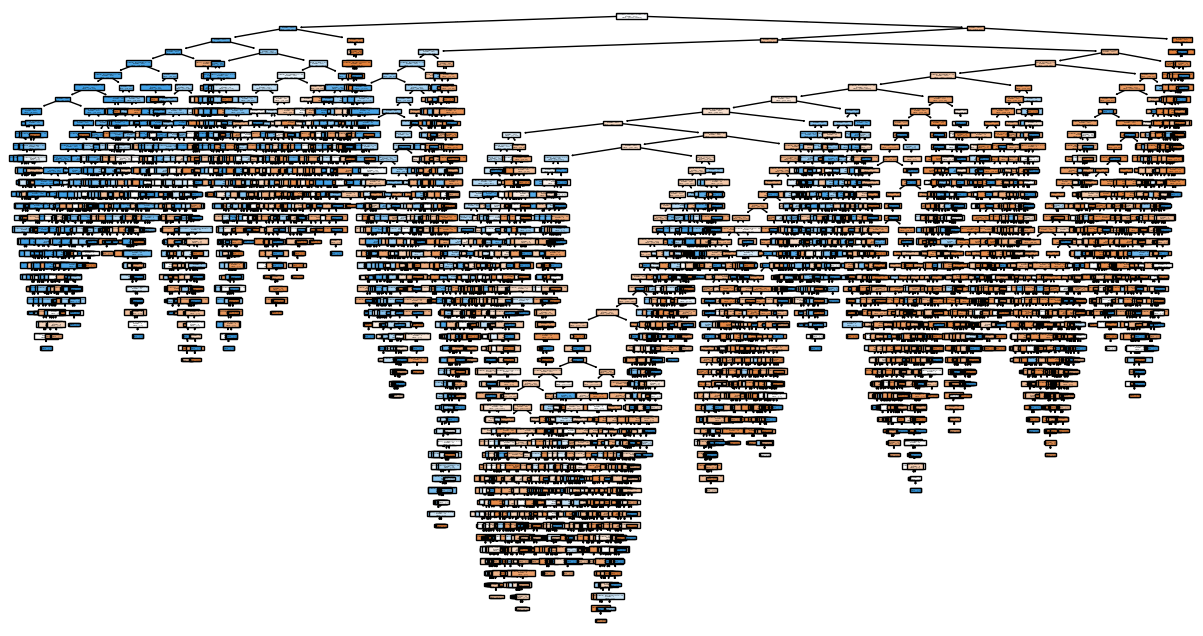

In [39]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
model_tree = DecisionTreeClassifier(random_state = 123)
model_tree.fit(X_train, y_train)
print(f'Profundidad del árbol: {model_tree.get_depth()}\nNúmero de hojas: {model_tree.get_n_leaves()}')
fig, ax = plt.subplots(figsize=(15,8))
plot = plot_tree(decision_tree = model_tree, feature_names = labels, filled = True, impurity = False, ax=ax) #gini por defecto

In [41]:
model_4 = DecisionTreeClassifier(random_state=123)
param_grid = {'criterion':['entropy','gini','log_loss'],'max_depth':[5,10,15,30,48],'max_leaf_nodes':[100,1000,2000,3000,4000,None],'min_samples_split':[2,4,6]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state = 123)
clf_4 = GridSearchCV(estimator=model_4, param_grid=param_grid, cv=cv, scoring='f1_weighted', n_jobs=-1)
clf_4.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...dom_state=123)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['entropy', 'gini', ...], 'max_depth': [5, 10, ...], 'max_leaf_nodes': [100, 1000, ...], 'min_samples_split': [2, 4, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1

In [42]:
validation = pd.concat([pd.DataFrame(clf_4.cv_results_['params']),
                        pd.DataFrame(clf_4.cv_results_['mean_test_score'],columns = ['F1_score'])], axis = 1)
validation.sort_values('F1_score', ascending=False)

,criterion,max_depth,max_leaf_nodes,min_samples_split,F1_score
174,gini,48,4000.0,2,0.885127
177,gini,48,NaN,2,0.885092
264,log_loss,48,4000.0,2,0.884153
84,entropy,48,4000.0,2,0.884153
87,entropy,48,NaN,2,0.884148
...,...,...,...,...,...
17,entropy,5,NaN,6,0.779003
15,entropy,5,NaN,2,0.779003
195,log_loss,5,NaN,2,0.779003
197,log_loss,5,NaN,6,0.779003


### Ensamble
1. ExtraTreeClassifier (stacking)

In [43]:
from sklearn.ensemble import ExtraTreesClassifier
model_5 = ExtraTreesClassifier(random_state=123)
param_grid = {
    'criterion':['entropy','gini','log_loss'], 
    'max_depth':[5,10,15,30,48], 
    'max_leaf_nodes':[100,1000,2000,3000,4341],
    'min_samples_split':[2,4,6],
    'n_estimators':[100,200,400,500]}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
clf_5 = GridSearchCV(estimator=model_5, param_grid=param_grid, cv=cv, scoring='f1_weighted', n_jobs=-1)
clf_5.fit(X_train,y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",ExtraTreesCla...dom_state=123)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['entropy', 'gini', ...], 'max_depth': [5, 10, ...], 'max_leaf_nodes': [100, 1000, ...], 'min_samples_split': [2, 4, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages

In [44]:
validation = pd.concat([pd.DataFrame(clf_5.cv_results_['params']),
                        pd.DataFrame(clf_5.cv_results_['mean_test_score'],columns = ['F1_score'])], axis = 1)
validation.sort_values('F1_score', ascending=False)

,criterion,max_depth,max_leaf_nodes,min_samples_split,n_estimators,F1_score
588,gini,48,4341,2,100,0.886754
289,entropy,48,4341,2,200,0.886613
889,log_loss,48,4341,2,200,0.886613
890,log_loss,48,4341,2,400,0.886609
290,entropy,48,4341,2,400,0.886609
...,...,...,...,...,...,...
18,entropy,5,1000,4,400,0.757460
30,entropy,5,2000,4,400,0.757460
42,entropy,5,3000,4,400,0.757460
54,entropy,5,4341,4,400,0.757460


2. RandomForestClassifier (Bagging)

In [48]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

model_6 = RandomForestClassifier(random_state = 123)
param_grid = {'criterion':['entropy','gini','log_loss'],
              'max_depth':[5,10,15,30,48],
              'max_leaf_nodes':[100,1000,2000,3000,4341],
              'min_samples_split':[2,4,6],
              'n_estimators':[100,200,400,500]}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
clf_6 = RandomizedSearchCV(estimator=model_6, param_distributions=param_grid, cv=cv, scoring='f1_weighted', n_jobs=-1, n_iter=180)
clf_6.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...dom_state=123)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'criterion': ['entropy', 'gini', ...], 'max_depth': [5, 10, ...], 'max_leaf_nodes': [100, 1000, ...], 'min_samples_split': [2, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",180
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that ca

In [49]:
validation = pd.concat([pd.DataFrame(clf_6.cv_results_['params']),
                        pd.DataFrame(clf_6.cv_results_['mean_test_score'],columns = ['F1_score'])], axis = 1)
validation.sort_values('F1_score', ascending=False)

,n_estimators,min_samples_split,max_leaf_nodes,max_depth,criterion,F1_score
129,400,2,4341,30,gini,0.894560
138,400,2,3000,48,log_loss,0.893836
72,500,2,4341,30,entropy,0.893827
149,200,2,3000,30,gini,0.893528
22,500,2,3000,30,log_loss,0.893502
...,...,...,...,...,...,...
64,200,2,4341,5,entropy,0.779462
102,200,2,3000,5,entropy,0.779462
90,200,4,2000,5,log_loss,0.779367
128,200,4,3000,5,log_loss,0.779367


3. AdaptativeBoostingClassifier (Boosting)

In [50]:
from sklearn.ensemble import AdaBoostClassifier
model_7 = AdaBoostClassifier(random_state = 123)
param_grid = {'learning_rate':[0.01,0.1,1,10,100], "n_estimators":[100,200,300,400]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state = 123)
clf_7 = GridSearchCV(estimator=model_7, param_grid=param_grid, cv=cv, scoring='f1_weighted', n_jobs=-1)
clf_7.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",AdaBoostClass...dom_state=123)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is dis

In [51]:
validation = pd.concat([pd.DataFrame(clf_7.cv_results_['params']),
                        pd.DataFrame(clf_7.cv_results_['mean_test_score'],columns = ['F1_score'])], axis = 1)
validation.sort_values('F1_score', ascending=False)

,learning_rate,n_estimators,F1_score
11,1.00,400,0.818886
10,1.00,300,0.816470
9,1.00,200,0.812824
8,1.00,100,0.809265
7,0.10,400,0.788295
6,0.10,300,0.785266
5,0.10,200,0.784466
4,0.10,100,0.781783
3,0.01,400,0.779154
2,0.01,300,0.778762


4. GradientBoostingClassifier (Boosting)

In [53]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
model_8 = GradientBoostingClassifier(random_state=123)
param_grid = {'criterion':['fried,am_mse','squared_error'],
                           'max_depth':[10,15,30,48],
                           'max_leaf_nodes':[1000,2000,None],
                           'min_samples_split':[2,3],
                           'n_estimators':[100,200,300,400]}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
clf_8 = RandomizedSearchCV(estimator=model_8, param_distributions=param_grid, cv=cv, scoring='f1_weighted', n_jobs=-1, n_iter=48)
clf_8.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...dom_state=123)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'criterion': ['fried,am_mse', 'squared_error'], 'max_depth': [10, 15, ...], 'max_leaf_nodes': [1000, 2000, ...], 'min_samples_split': [2, 3], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",48
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies th

In [54]:
validation = pd.concat([pd.DataFrame(clf_8.cv_results_['params']),
                        pd.DataFrame(clf_8.cv_results_['mean_test_score'],columns = ['F1_score'])], axis = 1)
validation.sort_values('F1_score', ascending=False)

,n_estimators,min_samples_split,max_leaf_nodes,max_depth,criterion,F1_score
31,300,3,2000.0,48,squared_error,0.900560
12,300,2,2000.0,30,squared_error,0.900235
19,200,2,2000.0,48,squared_error,0.900203
43,400,2,2000.0,30,squared_error,0.899946
11,200,3,2000.0,48,squared_error,0.899668
2,400,3,1000.0,30,squared_error,0.899634
26,400,2,1000.0,10,squared_error,0.898622
21,400,2,2000.0,10,squared_error,0.898622
22,200,3,2000.0,15,squared_error,0.898538
41,400,2,1000.0,30,squared_error,0.898497


In [55]:
#Red neuronal artifical - perceptron multicapa
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.model_selection import RandomizedSearchCV
model_9 = MLPClassifier(random_state=123)
param_grid = {'hidden_layer_sizes': [(10,), (20, 10,5), (20, 10,), (20,), (50,40,30,20,10)], 
              'activation': ['relu', 'tanh', 'logistic'], 
              'solver': ['lbfgs', 'sgd', 'adam'], 
              'learning_rate_init': [0.01, 0.1, 1, 10, 100],
              'max_iter': [50, 70, 100,200]} # hidden_layer_sizes es el numero de capas ocultas y el numero de neuronas en cada capa, activation es la funcion de activacion, solver es el algoritmo de optimizacion, alpha es la tasa de regularizacion
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123) # Que haga 5 experimentos asegurando que las clases estan repartidas
clf_9 = RandomizedSearchCV(estimator = model_9, param_distributions = param_grid, cv = cv, scoring= 'f1_weighted', n_jobs=-1, n_iter=200)
clf_9.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",MLPClassifier...dom_state=123)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'activation': ['relu', 'tanh', ...], 'hidden_layer_sizes': [(10,), (20, ...), ...], 'learning_rate_init': [0.01, 0.1, ...], 'max_iter': [50, 70, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",200
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation str

In [56]:
validation = pd.concat([pd.DataFrame(clf_9.cv_results_['params']), 
                        pd.DataFrame(clf_9.cv_results_['mean_test_score'], columns = ['F1_score'])], axis = 1)
validation.sort_values('F1_score', ascending = False)

,solver,max_iter,learning_rate_init,hidden_layer_sizes,activation,F1_score
184,adam,200,0.01,"(50, 40, 30, 20, 10)",relu,0.848253
122,adam,100,0.01,"(50, 40, 30, 20, 10)",relu,0.847696
159,sgd,100,0.10,"(50, 40, 30, 20, 10)",relu,0.844179
24,sgd,200,0.01,"(50, 40, 30, 20, 10)",tanh,0.842712
33,adam,200,0.01,"(20, 10)",tanh,0.837780
...,...,...,...,...,...,...
58,sgd,70,10.00,"(20, 10)",tanh,0.330558
138,sgd,100,100.00,"(50, 40, 30, 20, 10)",logistic,0.330558
123,sgd,50,100.00,"(50, 40, 30, 20, 10)",logistic,0.330558
54,adam,200,1.00,"(20, 10, 5)",logistic,0.328702


# **8. Validaciones del Modelo**
- Calcular las predicciones del conjunto de validacion
- Calcular las metricas de desempeño
- elegir el mejor modelo

In [57]:
model_rl= clf_1.best_estimator_
pred_rl = model_rl.predict(X_test)
model_knn = clf_2.best_estimator_
pred_knn = model_knn.predict(X_test)
model_svm = clf_3.best_estimator_
pred_svm = model_svm.predict(X_test)
model_dt = clf_4.best_estimator_
pred_dt = model_dt.predict(X_test)
model_et = clf_5.best_estimator_
pred_et = model_et.predict(X_test)
model_rf = clf_6.best_estimator_
pred_rf = model_rf.predict(X_test)
model_ab = clf_7.best_estimator_
pred_ab = model_ab.predict(X_test)
model_gb = clf_8.best_estimator_
pred_gb = model_gb.predict(X_test)
model_rna = clf_9.best_estimator_
pred_rna = model_rna.predict(X_test) 

In [58]:
from sklearn.metrics import classification_report, confusion_matrix

In [61]:
def calculo_metricas(y_test, pred_test, model):
    print(f'Metricas de Desempeño para {model} en Validación')
    print(classification_report(y_test, pred_test))
    sns.heatmap(confusion_matrix(y_test, pred_test), annot = True, fmt = 'd')
    plt.show()

Metricas de Desempeño para Regresion Logistica en Validación
                               precision    recall  f1-score   support

          greater than 50,000       0.81      0.84      0.83      6929
 less than or equal to 50,000       0.83      0.80      0.81      6664

                     accuracy                           0.82     13593
                    macro avg       0.82      0.82      0.82     13593
                 weighted avg       0.82      0.82      0.82     13593



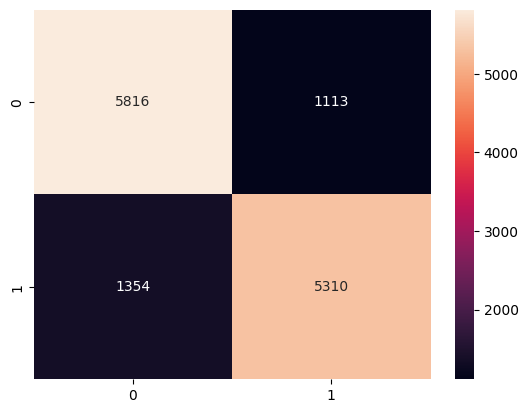

In [62]:
calculo_metricas(y_test, pred_rl, 'Regresion Logistica')

Metricas de Desempeño para K vecinos mas cercanos en Validación
                               precision    recall  f1-score   support

          greater than 50,000       0.82      0.89      0.85      6929
 less than or equal to 50,000       0.88      0.79      0.83      6664

                     accuracy                           0.84     13593
                    macro avg       0.85      0.84      0.84     13593
                 weighted avg       0.85      0.84      0.84     13593



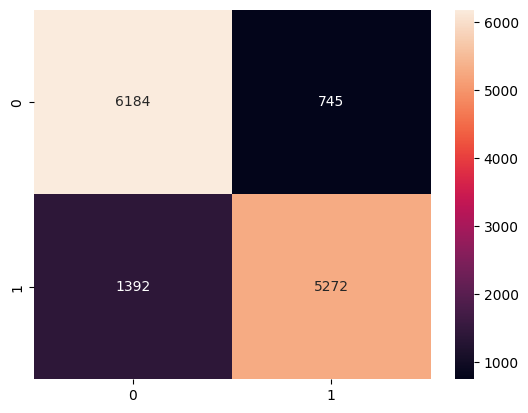

In [63]:
calculo_metricas(y_test, pred_knn, 'K vecinos mas cercanos')

Metricas de Desempeño para SVM en Validación
                               precision    recall  f1-score   support

          greater than 50,000       0.81      0.90      0.85      6929
 less than or equal to 50,000       0.88      0.78      0.83      6664

                     accuracy                           0.84     13593
                    macro avg       0.85      0.84      0.84     13593
                 weighted avg       0.84      0.84      0.84     13593



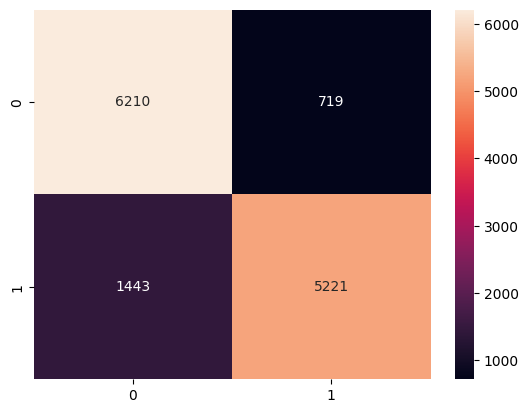

In [64]:
calculo_metricas(y_test, pred_svm, 'SVM')

Metricas de Desempeño para Decision Tree en Validación
                               precision    recall  f1-score   support

          greater than 50,000       0.86      0.95      0.90      6929
 less than or equal to 50,000       0.94      0.84      0.89      6664

                     accuracy                           0.89     13593
                    macro avg       0.90      0.89      0.89     13593
                 weighted avg       0.90      0.89      0.89     13593



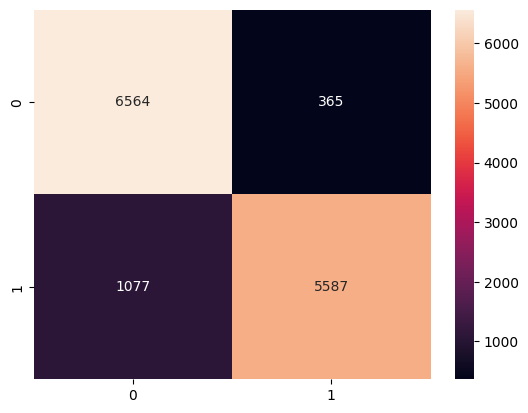

In [65]:
calculo_metricas(y_test, pred_dt, 'Decision Tree')

Metricas de Desempeño para Extra Trees en Validación
                               precision    recall  f1-score   support

          greater than 50,000       0.86      0.95      0.90      6929
 less than or equal to 50,000       0.94      0.83      0.88      6664

                     accuracy                           0.89     13593
                    macro avg       0.90      0.89      0.89     13593
                 weighted avg       0.90      0.89      0.89     13593



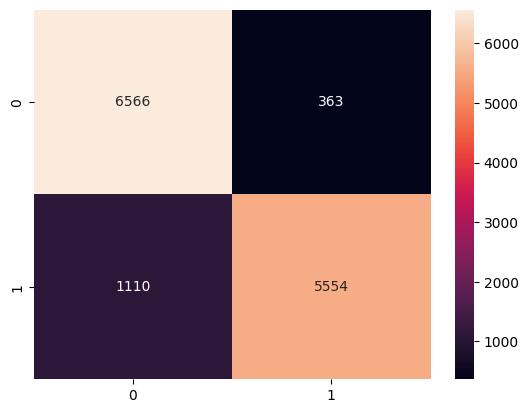

In [66]:
calculo_metricas(y_test, pred_et, 'Extra Trees')

Metricas de Desempeño para Random Forest en Validación
                               precision    recall  f1-score   support

          greater than 50,000       0.87      0.95      0.91      6929
 less than or equal to 50,000       0.94      0.85      0.89      6664

                     accuracy                           0.90     13593
                    macro avg       0.91      0.90      0.90     13593
                 weighted avg       0.90      0.90      0.90     13593



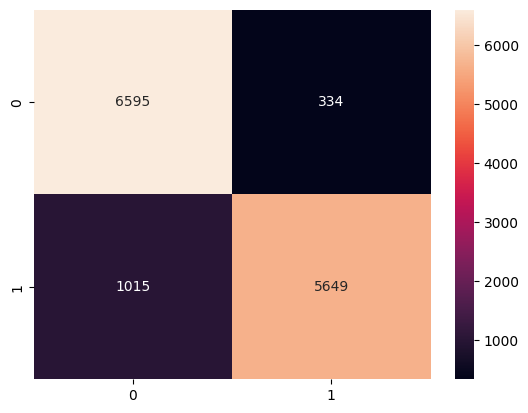

In [67]:
calculo_metricas(y_test, pred_rf, 'Random Forest')

Metricas de Desempeño para Adaptative Boosting en Validación
                               precision    recall  f1-score   support

          greater than 50,000       0.81      0.84      0.83      6929
 less than or equal to 50,000       0.83      0.79      0.81      6664

                     accuracy                           0.82     13593
                    macro avg       0.82      0.82      0.82     13593
                 weighted avg       0.82      0.82      0.82     13593



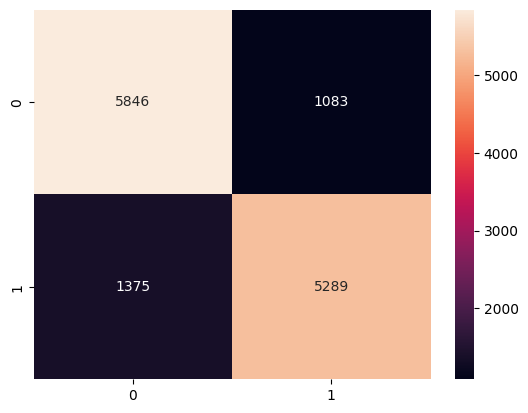

In [68]:
calculo_metricas(y_test, pred_ab, 'Adaptative Boosting')

Metricas de Desempeño para Gradient Boosting en Validación
                               precision    recall  f1-score   support

          greater than 50,000       0.89      0.94      0.91      6929
 less than or equal to 50,000       0.94      0.87      0.90      6664

                     accuracy                           0.91     13593
                    macro avg       0.91      0.91      0.91     13593
                 weighted avg       0.91      0.91      0.91     13593



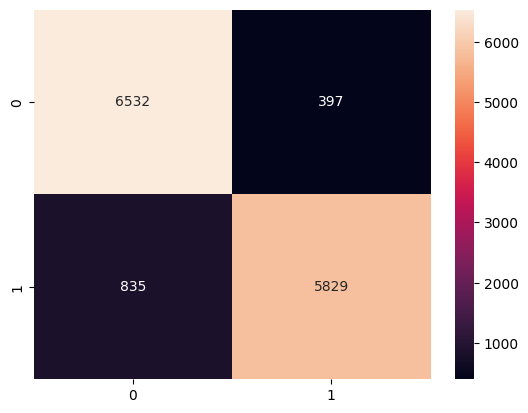

In [69]:
calculo_metricas(y_test, pred_gb, 'Gradient Boosting')

Metricas de Desempeño para Red neuronal artificial en Validación
                               precision    recall  f1-score   support

          greater than 50,000       0.83      0.89      0.86      6929
 less than or equal to 50,000       0.88      0.81      0.84      6664

                     accuracy                           0.85     13593
                    macro avg       0.85      0.85      0.85     13593
                 weighted avg       0.85      0.85      0.85     13593



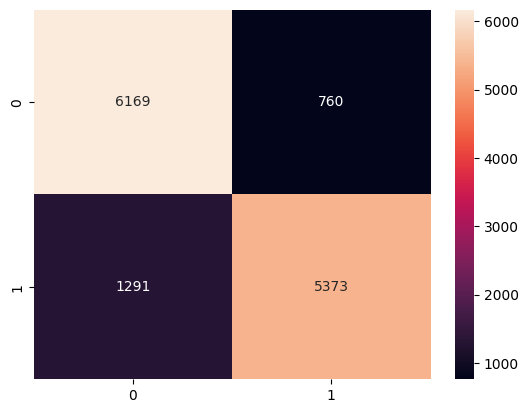

In [70]:
calculo_metricas(y_test, pred_rna, 'Red neuronal artificial')

In [71]:
data = pd.read_csv('datos_caso_5.csv')
target = 'SalStat'
x = data.drop(columns = target)
y = data[[target]]

In [72]:
ignored = ['race', 'nativecountry']
all_num = x.select_dtypes(include = ['int64', 'float64']).columns.to_list()
all_cat = x.select_dtypes(include = ['object']).columns.to_list()   
num_features = [col for col in all_num if col not in ignored]
cat_features = [col for col in all_cat if col not in ignored]

In [73]:
from sklearn.impute import SimpleImputer, KNNImputer
num_pipe = Pipeline(steps = [('num_imputer', KNNImputer()), ('scaler', MinMaxScaler())])
num_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('num_imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan or None, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`should be set to np.nan, since `pd.NA` will be converted to np.nan.",nan
,"n_neighbors n_neighbors: int, default=5Number of neighboring samples to use for imputation.",5
,"weights weights: {'uniform', 'distance'} or callable, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- callable : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.",'uniform'
,"metric metric: {'nan_euclidean'} or callable, default='nan_euclidean'Distance metric for searching neighbors. Possible values:- 'nan_euclidean'- callable : a user-defined function which conforms to the definition of ``func_metric(x, y, *, missing_values=np.nan)``. `x` and `y` corresponds to a row (i.e. 1-D arrays) of `X` and `Y`, respectively. The callable should returns a scalar distance value.",'nan_euclidean'
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto theoutput of the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear on themissing indicator even if there are missing values at transform/testtime.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0`... versionadded:: 1.2",False

In [75]:
cat_pipe = Pipeline(steps = [('cat_imputer', SimpleImputer(strategy = 'most_frequent')), ('encoder', OneHotEncoder(sparse_output=False))])
cat_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('cat_imputer', ...), ('encoder', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputa

In [76]:
model_gb

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",3
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",48
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``

In [77]:
prepocessor = ColumnTransformer(transformers = [('num', num_pipe, num_features),
                                               ('cat', cat_pipe, cat_features)],
                                               remainder='drop')
model = GradientBoostingClassifier(max_depth=48,criterion='squared_error',n_estimators=300, random_state=123, max_leaf_nodes=2000, min_samples_split=3)
pipe_model = Pipeline(steps = [('prepocessor', prepocessor), ('model', model)])
pipe_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prepocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers con

In [78]:
X_train, X_test, y_train, y_test = train_test_split(x, y, train_size = 0.7, random_state= 123)
pipe_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prepocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers con

In [79]:
pipe_model.predict(X_test)

array([' less than or equal to 50,000', ' less than or equal to 50,000',
       ' less than or equal to 50,000', ...,
       ' less than or equal to 50,000', ' less than or equal to 50,000',
       ' less than or equal to 50,000'], shape=(9594,), dtype=object)

In [80]:
import joblib
joblib.dump(pipe_model, 'salstat_model_clasification.pkl')

['salstat_model_clasification.pkl']

In [82]:
import pandas as pd
import joblib

model_prueba_pipeline = joblib.load('salstat_model_clasification.pkl')

data_Prueba_Pipeline = [
    [38, " Private", " Bachelors", " Married-civ-spouse", " Exec-managerial", " Husband", " White", " Male", 0, 0, 50, " United-States", " greater than 50,000"],
    [29, " Private", " Some-college", " Never-married", " Tech-support", " Not-in-family", " Black", " Female", 0, 0, 38, " United-States", " less than or equal to 50,000"],
    [52, " Private", " HS-grad", " Widowed", " Machine-op-inspct", " Unmarried", " White", " Female", 0, 0, 45, " Canada", " less than or equal to 50,000"],
    [41, " State-gov", " Masters", " Married-civ-spouse", " Prof-specialty", " Wife", " Asian-Pac-Islander", " Female", 5000, 0, 40, " India", " greater than 50,000"],
    [33, " Private", " Bachelors", " Divorced", " Sales", " Not-in-family", " White", " Male", 0, 0, 60, " United-States", " greater than 50,000"]
]

columns = [
    "age", "JobType", "EdType", "maritalstatus", "occupation",
    "relationship", "race", "gender", "capitalgain", "capitalloss",
    "hoursperweek", "nativecountry", "SalStat"
]

df_prueba_pipeline = pd.DataFrame(data_Prueba_Pipeline, columns=columns)

predictions = model_prueba_pipeline.predict(df_prueba_pipeline)

print(predictions)

[' greater than 50,000' ' less than or equal to 50,000'
 ' less than or equal to 50,000' ' less than or equal to 50,000'
 ' greater than 50,000']


In [83]:
print(df_prueba_pipeline)

   age     JobType         EdType        maritalstatus          occupation  \
0   38     Private      Bachelors   Married-civ-spouse     Exec-managerial   
1   29     Private   Some-college        Never-married        Tech-support   
2   52     Private        HS-grad              Widowed   Machine-op-inspct   
3   41   State-gov        Masters   Married-civ-spouse      Prof-specialty   
4   33     Private      Bachelors             Divorced               Sales   

     relationship                 race   gender  capitalgain  capitalloss  \
0         Husband                White     Male            0            0   
1   Not-in-family                Black   Female            0            0   
2       Unmarried                White   Female            0            0   
3            Wife   Asian-Pac-Islander   Female         5000            0   
4   Not-in-family                White     Male            0            0   

   hoursperweek   nativecountry                        SalStat  
0  